In [ ]:
!unzip /content/drive/MyDrive/welding_defect_dataset_classified.zip

Archive:  /content/drive/MyDrive/welding_defect_dataset_classified.zip
   creating: bad_weld/
   creating: good_weld/
  inflating: good_weld/SampleV1_1_mp4-41_jpg.rf.043eed81de49a2135ccf91164c99d0e6.jpg  
  inflating: good_weld/good_weld_vid1927_jpeg.rf.8f8420b00fb1970ecd112060465cb718.jpg  
  inflating: good_weld/good_weld_vid862_jpeg_jpg.rf.8b859eced0331846ba1fd614f4468c03.jpg  
  inflating: good_weld/good_weld_vid708_jpeg.rf.a0ca6fb64463032c08589d143fe13574.jpg  
  inflating: good_weld/good_weld_vid1770_jpeg.rf.5ede94d7661002ef99197a6a3eddebb0.jpg  
  inflating: good_weld/carbon-steel-good-welds_4_jpeg_jpg.rf.4c5dab2d305a158bb4ee52ced8b26dfa.jpg  
  inflating: good_weld/good_weld_vid863_jpeg.rf.59054f52363c894799b15be7746b4111.jpg  
  inflating: good_weld/Good-Welding-images_22_jpeg.rf.96f21783d77da336e9ce6492e9b9cf2f.jpg  
  inflating: good_weld/crack-welding-images_12_jpeg.rf.5e6844a1b19b96db44dcc0d423b6d41f.jpg  
  inflating: good_weld/good_weld_vid109_jpeg.rf.c9e6be60c579ab122fd

In [ ]:
from google.colab import drive
import os
import numpy as np
import matplotlib.pyplot as plt
import shutil
import joblib
import random
import tensorflow as tf
from tensorflow.keras import layers, preprocessing
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
!pip install keras-cv
import keras_cv
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import StratifiedKFold, StratifiedGroupKFold
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from xgboost import XGBClassifier

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 650.7/650.7 kB 18.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 950.8/950.8 kB 57.3 MB/s eta 0:00:00


In [ ]:
good_weld_dir = "/content/good_weld"
defects_dir = "/content/bad_weld"

good_weld_files = os.listdir(good_weld_dir)
defects_files = os.listdir(defects_dir)

In [ ]:
IMG_HEIGHT = 300
IMG_WIDTH = 300
BATCH_SIZE = 32
CHANNELS = 3
classes = ['good_weld', 'defects']

def preprocess_image(image_path, target_size=(IMG_HEIGHT, IMG_WIDTH)):

    try:

        image = tf.io.read_file(image_path)
        image = tf.image.decode_image(image, channels=CHANNELS)


        image = tf.image.resize(image, target_size)
        image = tf.image.convert_image_dtype(image, tf.float32)


        # Removed image = image / 255.0 to avoid double preprocessing with model's internal layer

        return image
    except:
        return None

def load_and_preprocess_data():


    image_paths = []
    labels = []


    for img_name in good_weld_files:
        image_paths.append(os.path.join(good_weld_dir, img_name))
        labels.append(1)


    for img_name in defects_files:
        image_paths.append(os.path.join(defects_dir, img_name))
        labels.append(0)

    return np.array(image_paths), np.array(labels)

image_paths, labels = load_and_preprocess_data()

In [ ]:
X_train_paths, X_temp_paths, y_train, y_temp = train_test_split(
    image_paths, labels,
    test_size=0.3,
    random_state=42,
    stratify=labels
)


X_val_paths, X_test_paths, y_val, y_test = train_test_split(
    X_temp_paths, y_temp,
    test_size=0.5,
    random_state=42,
    stratify=y_temp
)

In [ ]:

train_datagen = ImageDataGenerator()
val_test_datagen = ImageDataGenerator()

# Refactored function to create a data generator for a given set of paths and labels
def create_image_generator(image_paths, labels, generator_name, shuffle=True):
    temp_base_dir = "/tmp/kfold_data"
    current_temp_dir = os.path.join(temp_base_dir, generator_name)

    # Clean up previous temporary directory if it exists
    if os.path.exists(current_temp_dir):
        shutil.rmtree(current_temp_dir)

    os.makedirs(os.path.join(current_temp_dir, "good_weld"), exist_ok=True)
    os.makedirs(os.path.join(current_temp_dir, "defects"), exist_ok=True)

    # Helper function to copy files
    def copy_files_to_temp_dir(paths, lbls, target_dir):
        for path, label in zip(paths, lbls):
            class_name = "good_weld" if label == 1 else "defects"
            filename = os.path.basename(path)
            target_path = os.path.join(target_dir, class_name, filename)
            shutil.copy2(path, target_path)

    copy_files_to_temp_dir(image_paths, labels, current_temp_dir)

    # Use the appropriate ImageDataGenerator instance
    if generator_name == "train":
        datagen_instance = train_datagen
    else:
        datagen_instance = val_test_datagen

    generator = datagen_instance.flow_from_directory(
        current_temp_dir,
        target_size=(IMG_HEIGHT, IMG_WIDTH),
        batch_size=BATCH_SIZE,
        class_mode='binary',
        shuffle=shuffle
    )
    return generator

# Now, create the train, validation, and test generators using the new flexible function
print("Creating data generators for initial train/val/test split...")

train_gen = create_image_generator(X_train_paths, y_train, "train", shuffle=True)
val_gen = create_image_generator(X_val_paths, y_val, "val", shuffle=False)
test_gen = create_image_generator(X_test_paths, y_test, "test", shuffle=False)

print(f"✅ Training generator: {train_gen.samples} samples")
print(f"✅ Validation generator: {val_gen.samples} samples")
print(f"✅ Test generator: {test_gen.samples} samples")

# Explanation for K-Fold
print("\n--- Regarding Stratified Group K-Fold ---")
print("To implement Stratified Group K-Fold cross-validation, you would typically:")
print("1. Define your 'groups' (e.g., patient IDs, weld batches) if applicable. If no explicit groups, Stratified K-Fold can be used.")
print("2. Initialize StratifiedKFold or StratifiedGroupKFold from sklearn.model_selection.")
print("3. Loop through the splits generated by KFold.split(image_paths, labels, groups) to get train/validation indices for each fold.")
print("4. Inside the loop, create temporary train and validation image generators for each fold using the 'create_image_generator' function above.")
print("5. Train and evaluate your model within each fold, then aggregate the results.")
print("This refactored 'create_image_generator' function is designed to be reusable within such a K-Fold loop.")

Creating data generators for initial train/val/test split...
Found 1441 images belonging to 2 classes.
Found 309 images belonging to 2 classes.
Found 309 images belonging to 2 classes.
✅ Training generator: 1441 samples
✅ Validation generator: 309 samples
✅ Test generator: 309 samples

--- Regarding Stratified Group K-Fold ---
To implement Stratified Group K-Fold cross-validation, you would typically:
1. Define your 'groups' (e.g., patient IDs, weld batches) if applicable. If no explicit groups, Stratified K-Fold can be used.
2. Initialize StratifiedKFold or StratifiedGroupKFold from sklearn.model_selection.
3. Loop through the splits generated by KFold.split(image_paths, labels, groups) to get train/validation indices for each fold.
4. Inside the loop, create temporary train and validation image generators for each fold using the 'create_image_generator' function above.
5. Train and evaluate your model within each fold, then aggregate the results.
This refactored 'create_image_generat

In [ ]:
early_stopping  = tf.keras.callbacks.EarlyStopping(monitor= 'val_loss' ,
                                                   patience = 5, min_delta = 0.001 , verbose = 1)
reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss",
                                                 factor=0.2,
                                                 patience=3,
                                                 verbose=1,
                                                 min_lr=1e-7)

In [ ]:
tf.keras.backend.clear_session()
Epochs=8

Data_Aug=tf.keras.Sequential([
    #layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.4),
    layers.RandomZoom(0.3),
    layers.RandomContrast(0.2),
    #layers.RandomTranslation(height_factor=0.2, width_factor=0.2)
])

inputs=tf.keras.layers.Input(shape=(300,300,3))
x=Data_Aug(inputs)
x=tf.keras.applications.resnet_v2.preprocess_input(x)
base_model = tf.keras.applications.ResNet50V2(
    include_top=False,
    weights='imagenet',
    input_tensor=x
)
base_model.trainable = False
x = base_model.output
avg_pool = layers.GlobalAveragePooling2D()(x)
max_pool = layers.GlobalMaxPooling2D()(x)
x = layers.Concatenate()([avg_pool, max_pool])
x=tf.keras.layers.BatchNormalization()(x)
x=tf.keras.layers.Dropout(0.5)(x)
x = tf.keras.layers.Dense(256, activation='relu',name="feature_extraction_layer")(x)
x=tf.keras.layers.BatchNormalization()(x)
x=tf.keras.layers.Dropout(0.5)(x)
outputs=tf.keras.layers.Dense(1,activation='sigmoid')(x)

model=tf.keras.Model(inputs,outputs)

model.compile(loss="binary_crossentropy",
              optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
              metrics=["Accuracy"])
history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=Epochs,
    callbacks=[early_stopping,reduce_lr],
    verbose=1
)

Epoch 1/8
46/46 ━━━━━━━━━━━━━━━━━━━━ 21s 300ms/step - Accuracy: 0.7259 - loss: 0.6722 - val_Accuracy: 0.5858 - val_loss: 1.9567 - learning_rate: 0.0010
Epoch 2/8
46/46 ━━━━━━━━━━━━━━━━━━━━ 12s 249ms/step - Accuracy: 0.7752 - loss: 0.5708 - val_Accuracy: 0.7476 - val_loss: 0.7187 - learning_rate: 0.0010
Epoch 3/8
46/46 ━━━━━━━━━━━━━━━━━━━━ 12s 256ms/step - Accuracy: 0.8001 - loss: 0.4801 - val_Accuracy: 0.7961 - val_loss: 0.4276 - learning_rate: 0.0010
Epoch 4/8
46/46 ━━━━━━━━━━━━━━━━━━━━ 11s 245ms/step - Accuracy: 0.8147 - loss: 0.4179 - val_Accuracy: 0.8285 - val_loss: 0.3873 - learning_rate: 0.0010
Epoch 5/8
46/46 ━━━━━━━━━━━━━━━━━━━━ 11s 244ms/step - Accuracy: 0.8397 - loss: 0.3957 - val_Accuracy: 0.8382 - val_loss: 0.3764 - learning_rate: 0.0010
Epoch 6/8
46/46 ━━━━━━━━━━━━━━━━━━━━ 12s 257ms/step - Accuracy: 0.8293 - loss: 0.3943 - val_Accuracy: 0.8511 - val_loss: 0.3379 - learning_rate: 0.0010
Epoch 7/8
46/46 ━━━━━━━━━━━━━━━━━━━━ 12s 254ms/step - Accuracy: 0.8459 - loss: 0.3795 - 

In [ ]:
model.trainable = True
for layer in model.layers[:-20]:
    layer.trainable = False
fine_tune_lr = 1e-5 # 0.00001
model.compile(
    loss="binary_crossentropy",
    optimizer=tf.keras.optimizers.Adam(learning_rate=fine_tune_lr),
    metrics=["Accuracy"]
)
# 4. Continue training
fine_history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=Epochs + 6,
    initial_epoch=history.epoch[-1],
    callbacks=[early_stopping,reduce_lr],
    verbose=1
)

Epoch 8/14
46/46 ━━━━━━━━━━━━━━━━━━━━ 21s 305ms/step - Accuracy: 0.8446 - loss: 0.3408 - val_Accuracy: 0.8447 - val_loss: 0.3180 - learning_rate: 1.0000e-05
Epoch 9/14
46/46 ━━━━━━━━━━━━━━━━━━━━ 12s 256ms/step - Accuracy: 0.8341 - loss: 0.3794 - val_Accuracy: 0.8511 - val_loss: 0.3157 - learning_rate: 1.0000e-05
Epoch 10/14
46/46 ━━━━━━━━━━━━━━━━━━━━ 12s 257ms/step - Accuracy: 0.8508 - loss: 0.3647 - val_Accuracy: 0.8511 - val_loss: 0.3142 - learning_rate: 1.0000e-05
Epoch 11/14
46/46 ━━━━━━━━━━━━━━━━━━━━ 12s 252ms/step - Accuracy: 0.8543 - loss: 0.3445 - val_Accuracy: 0.8511 - val_loss: 0.3136 - learning_rate: 1.0000e-05
Epoch 12/14
46/46 ━━━━━━━━━━━━━━━━━━━━ 12s 246ms/step - Accuracy: 0.8494 - loss: 0.3280 - val_Accuracy: 0.8511 - val_loss: 0.3122 - learning_rate: 1.0000e-05
Epoch 13/14
46/46 ━━━━━━━━━━━━━━━━━━━━ 12s 257ms/step - Accuracy: 0.8446 - loss: 0.3457 - val_Accuracy: 0.8544 - val_loss: 0.3109 - learning_rate: 1.0000e-05
Epoch 14/14
46/46 ━━━━━━━━━━━━━━━━━━━━ 12s 256ms/step 

In [ ]:
feature_extractor_model = tf.keras.Model(inputs=model.input, outputs=model.get_layer("feature_extraction_layer").output)
def get_xgb_data(generator):
    feats, labels = [], []
    for _ in range(len(generator)):
        img, lbl = next(generator)
        f = feature_extractor_model.predict(img, verbose=0)
        feats.append(f)
        labels.append(lbl)
    return np.vstack(feats), np.concatenate(labels)

print("Extracting features for XGBoost...")
X_train_xgb, y_train_xgb = get_xgb_data(train_gen)
X_val_xgb, y_val_xgb = get_xgb_data(val_gen)
X_test_xgb,y_test_xgb=get_xgb_data(test_gen)
# --- SCALING ---
# XGBoost/SVM need scaled features to reach high accuracy
scaler = StandardScaler()
X_train_xgb = scaler.fit_transform(X_train_xgb)
X_val_xgb = scaler.transform(X_val_xgb)
X_test_xgb=scaler.transform(X_test_xgb)

# --- XGBOOST CLASSIFIER ---
print("Training XGBoost...")
model_xgb = XGBClassifier(
    n_estimators=100,
    max_depth=4,
    colsample_bytree=0.3,
    subsample=0.8,
    reg_lambda=10
)

model_xgb.fit(X_train_xgb, y_train_xgb)

# Check Accuracy
test_preds = model_xgb.predict(X_test_xgb)
final_acc = np.mean(test_preds == y_test_xgb)
print(f"Final Hybrid Accuracy: {final_acc * 100:.2f}%")

Extracting features for XGBoost...
Training XGBoost...
Final Hybrid Accuracy: 88.35%


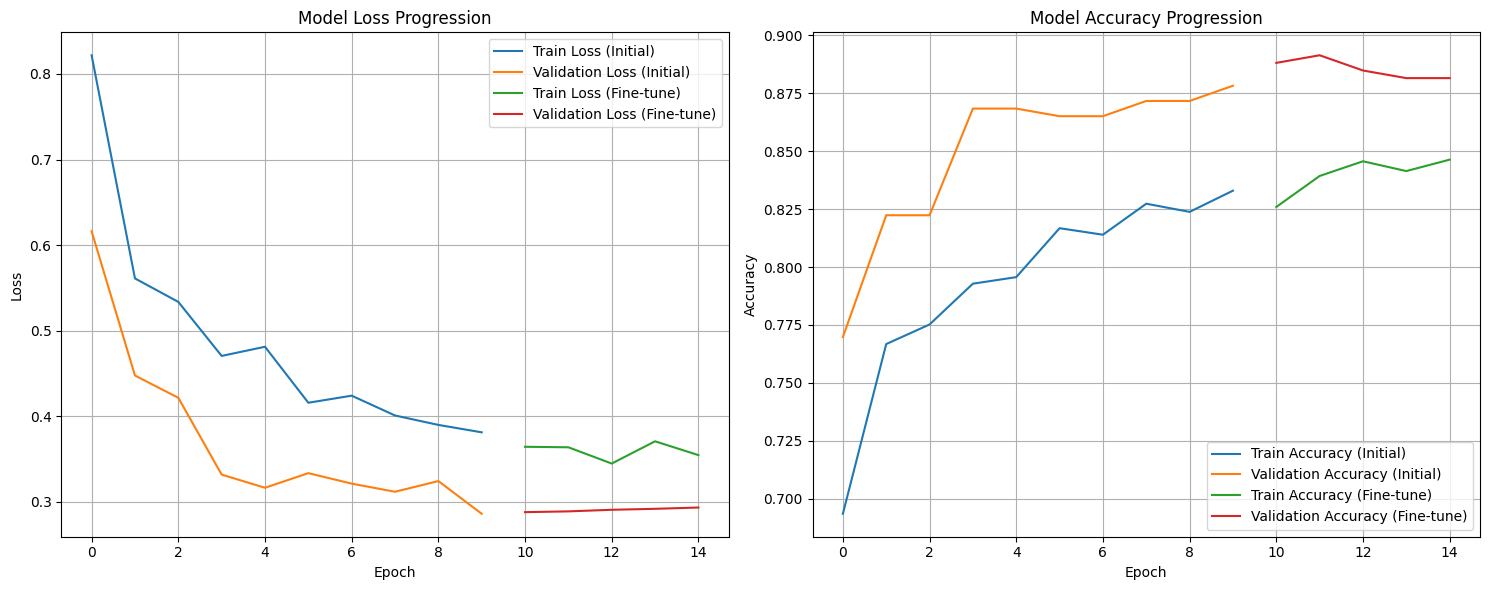

In [ ]:
# Plotting loss and accuracy curves for history and fine_history
plt.figure(figsize=(15, 6))

# Subplot 1: Loss
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss (Initial)')
plt.plot(history.history['val_loss'], label='Validation Loss (Initial)')

initial_epochs = len(history.history['loss'])
fine_tune_epochs = len(fine_history.history['loss'])

plt.plot(np.arange(initial_epochs, initial_epochs + fine_tune_epochs), fine_history.history['loss'], label='Train Loss (Fine-tune)')
plt.plot(np.arange(initial_epochs, initial_epochs + fine_tune_epochs), fine_history.history['val_loss'], label='Validation Loss (Fine-tune)')

plt.title('Model Loss Progression')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(loc='upper right')
plt.grid(True)

# Subplot 2: Accuracy
plt.subplot(1, 2, 2)
plt.plot(history.history['Accuracy'], label='Train Accuracy (Initial)')
plt.plot(history.history['val_Accuracy'], label='Validation Accuracy (Initial)')

plt.plot(np.arange(initial_epochs, initial_epochs + fine_tune_epochs), fine_history.history['Accuracy'], label='Train Accuracy (Fine-tune)')
plt.plot(np.arange(initial_epochs, initial_epochs + fine_tune_epochs), fine_history.history['val_Accuracy'], label='Validation Accuracy (Fine-tune)')

plt.title('Model Accuracy Progression')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(loc='lower right')
plt.grid(True)

plt.tight_layout()
plt.show()


Generating Confusion Matrix for XGBoost Model...


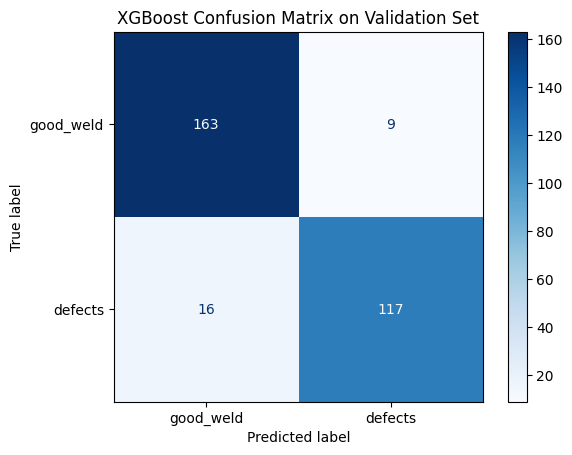

In [ ]:
print("\nGenerating Confusion Matrix for XGBoost Model...")

cm_xgb = confusion_matrix(y_test_xgb, test_preds)

disp_xgb = ConfusionMatrixDisplay(confusion_matrix=cm_xgb, display_labels=classes)
disp_xgb.plot(cmap=plt.cm.Blues)
plt.title('XGBoost Confusion Matrix on Validation Set')
plt.show()

In [ ]:

print("XGBoost Evaluation Metrics on Validation Set:")


accuracy = accuracy_score(y_test_xgb, test_preds)
precision = precision_score(y_test_xgb, test_preds)
recall = recall_score(y_test_xgb, test_preds)
f1 = f1_score(y_test_xgb, test_preds)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")

XGBoost Evaluation Metrics on Validation Set:
Accuracy: 0.8835
Precision: 0.8880
Recall: 0.8346
F1-score: 0.8605


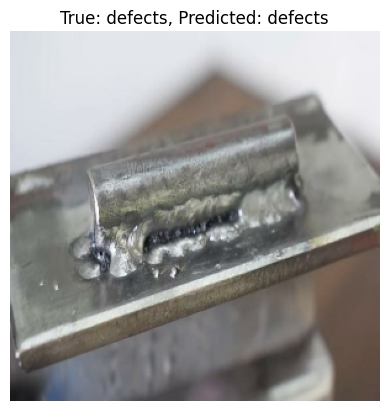

The image is predicted as: defects (True label: defects)


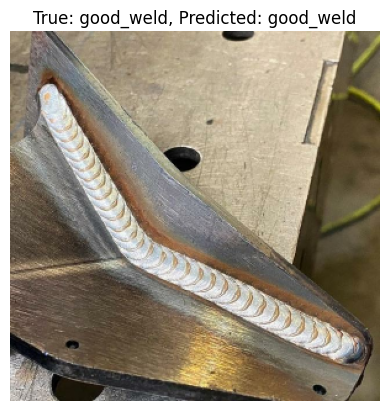

The image is predicted as: good_weld (True label: good_weld)


In [ ]:
classes = ['defects', 'good_weld']
def predict_image(image_path, true_label):
    # Load and preprocess the image
    image = preprocess_image(image_path)
    if image is None:
        print(f"Error loading or processing image: {image_path}")
        return

    # Add batch dimension (1, H, W, C)
    image_batch = tf.expand_dims(image, axis=0)

    # Extract features using the globally defined feature extractor
    extracted_features = feature_extractor_model.predict(image_batch, verbose=0)

    # Flatten the extracted features
    flat_features = extracted_features.reshape(1, -1)

    # Scale the features using the previously fitted scaler
    scaled_features = scaler.transform(flat_features)

    # Make prediction with XGBoost model
    xgb_prediction = model_xgb.predict(scaled_features)

    # Interpret the prediction
    predicted_class_index = int(xgb_prediction[0])
    predicted_class_name = classes[predicted_class_index]
    true_class_name = classes[true_label]

    # Display the image and prediction
    plt.imshow(image / 255.0) # Normalize image for display
    plt.title(f"True: {true_class_name}, Predicted: {predicted_class_name}")
    plt.axis('off')
    plt.show()

    print(f"The image is predicted as: {predicted_class_name} (True label: {true_class_name})")

# Example usage with images from the test dataset:

# Find an actual 'defects' image from the test set
bad_weld_indices = np.where(y_test == 0)[0]
if len(bad_weld_indices) > 0:
    bad_weld_test_idx = bad_weld_indices[0]
    bad_weld_test_path = X_test_paths[bad_weld_test_idx]
    bad_weld_true_label = y_test[bad_weld_test_idx]
    predict_image(bad_weld_test_path, bad_weld_true_label)
else:
    print("No 'defects' images found in the test set for demonstration.")

# Find an actual 'good_weld' image from the test set
good_weld_indices = np.where(y_test == 1)[0]
if len(good_weld_indices) > 0:
    good_weld_test_idx = good_weld_indices[0]
    good_weld_test_path = X_test_paths[good_weld_test_idx]
    good_weld_true_label = y_test[good_weld_test_idx]
    predict_image(good_weld_test_path, good_weld_true_label)
else:
    print("No 'good_weld' images found in the test set for demonstration.")

In [ ]:
# Mount Google Drive
drive.mount('/content/drive')

# Define the directory to save models in Google Drive
save_dir = '/content/drive/MyDrive/welding_models'
os.makedirs(save_dir, exist_ok=True)

# Save the Keras deep learning model
keras_model_path = os.path.join(save_dir, 'resnet_hybrid_keras_model_final.keras')
model.save(keras_model_path)
print(f"Keras model saved to: {keras_model_path}")

# Save the XGBoost model
xgb_model_path = os.path.join(save_dir, 'xgboost_classifier_model_final.joblib')
joblib.dump(model_xgb, xgb_model_path)
print(f"XGBoost model saved to: {xgb_model_path}")

# Save the StandardScaler
scaler_path = os.path.join(save_dir, 'scaler_final.joblib')
joblib.dump(scaler, scaler_path)
print(f"Scaler saved to: {scaler_path}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Keras model saved to: /content/drive/MyDrive/welding_models/resnet_hybrid_keras_model.keras
XGBoost model saved to: /content/drive/MyDrive/welding_models/xgboost_classifier_model.joblib
Scaler saved to: /content/drive/MyDrive/welding_models/scaler.joblib
